In [66]:
from pyforest import *
import duckdb as ddb

#import mticker
import matplotlib.ticker as mticker
#import mdate
import matplotlib.dates as mdates

In [12]:
con = ddb.connect()

In [10]:
data_all = pd.read_parquet('../sandbox/data_genex_venta_transfer.parquet')

<IPython.core.display.Javascript object>

In [25]:
query = """
SELECT *
FROM data_all
WHERE
cod_producto = 680279
AND cod_talla = 105
"""

sample = con.execute(query).df()

In [70]:
sample_gb = sample.groupby(
    ['week_start_date'],
    observed=False
).agg(
    total_stores = ('cod_sucursal', 'nunique'),
    stores_with_inventory = ('flag_inventory_available', 'sum'),
    weekly_available_stock = ('weekly_available_stock', 'sum'),
    weekly_sales = ('weekly_sales', 'sum')
).reset_index()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

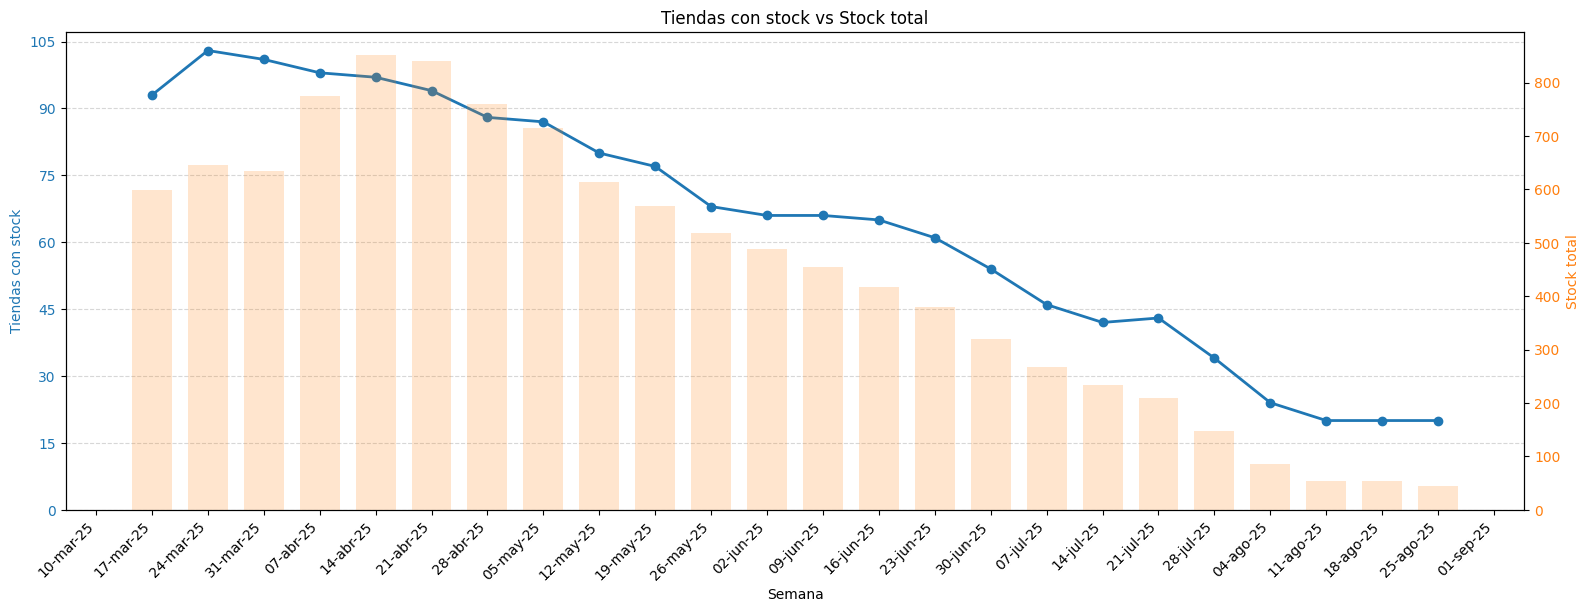

In [69]:
fig, ax1 = plt.subplots(figsize=(16, 6))

# Primer eje: línea
ax1.set_xlabel("Semana")
ax1.set_ylabel("Tiendas con stock", color="tab:blue")
ax1.plot(
    sample_gb["week_start_date"],
    sample_gb["stores_with_inventory"],
    color="tab:blue",
    label="Tiendas con stock",
    linewidth=2,
    marker="o"
)
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.set_ylim(bottom=0)
ax1.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax1.grid(visible=True, which="both", axis="y", linestyle="--", alpha=0.5)
ax1.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%d-%b-%y"))
plt.setp(ax1.get_xticklabels(), rotation=45, ha="right")

# Segundo eje: barras
ax2 = ax1.twinx()
ax2.set_ylabel("Stock total", color="tab:orange")
ax2.bar(
    sample_gb["week_start_date"],
    sample_gb["weekly_available_stock"],
    color="tab:orange",
    alpha=0.2,   # un poco transparente para no tapar la línea
    label="Stck total",
    width=5  # ancho de las barras
)
ax2.tick_params(axis="y", labelcolor="tab:orange")
ax2.set_ylim(bottom=0)

# Título y layout
fig.tight_layout()
plt.title("Tiendas con stock vs Stock total")
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

35


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

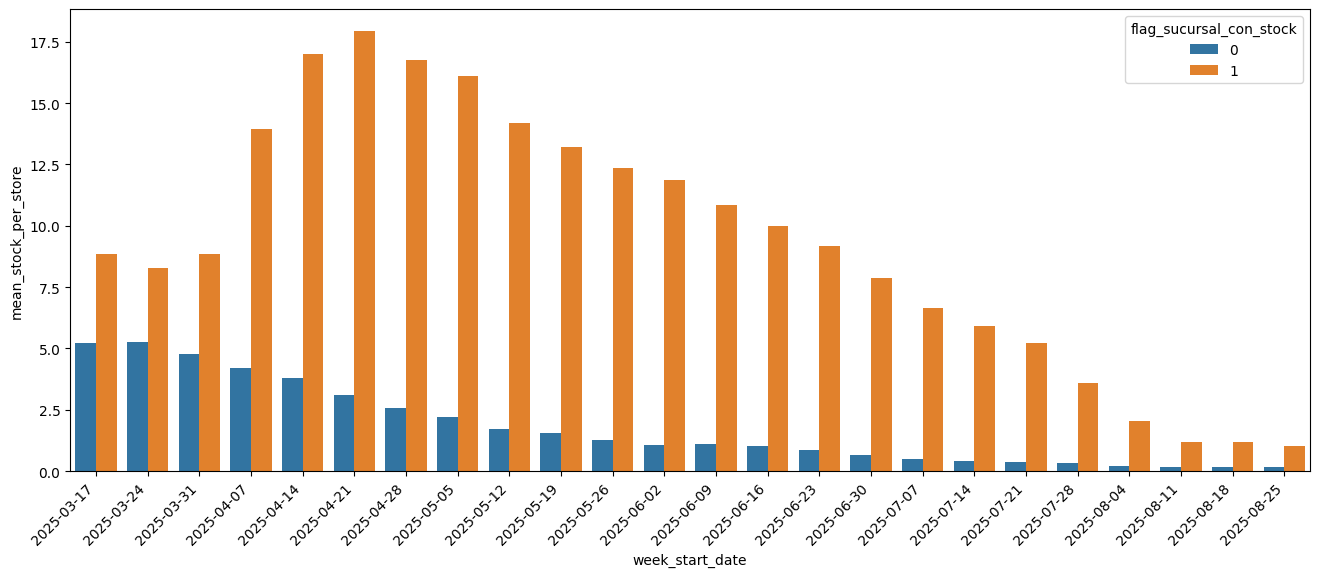

In [101]:
sucursales_con_stock = sample.query('week_start_date == @pd.Timestamp("2025-04-28") and weekly_available_stock > 6')[['cod_sucursal']]
print(len(sucursales_con_stock))
sample['flag_sucursal_con_stock'] = sample['cod_sucursal'].isin(sucursales_con_stock['cod_sucursal']).astype(int)

sample_gb_suc = sample.groupby(
    ['week_start_date', 'flag_sucursal_con_stock'],
    observed=False
).agg(
    total_stores = ('cod_sucursal', 'nunique'),
    stores_with_inventory = ('flag_inventory_available', 'sum'),
    weekly_available_stock = ('weekly_available_stock', 'sum'),
    weekly_sales = ('weekly_sales', 'sum')
).reset_index()

sample_gb_suc['mean_stock_per_store'] = (sample_gb_suc['weekly_available_stock'] / sample_gb_suc['total_stores']).round(2)
sample_gb_suc['mean_sales_per_store'] = (sample_gb_suc['weekly_sales'] / sample_gb_suc['total_stores']).round(2)


plt.figure(figsize=(16, 6))

sns.barplot(
    data=sample_gb_suc,
    x='week_start_date',
    y='mean_stock_per_store',
    hue='flag_sucursal_con_stock'
)

plt.xticks(rotation=45, ha='right')

plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

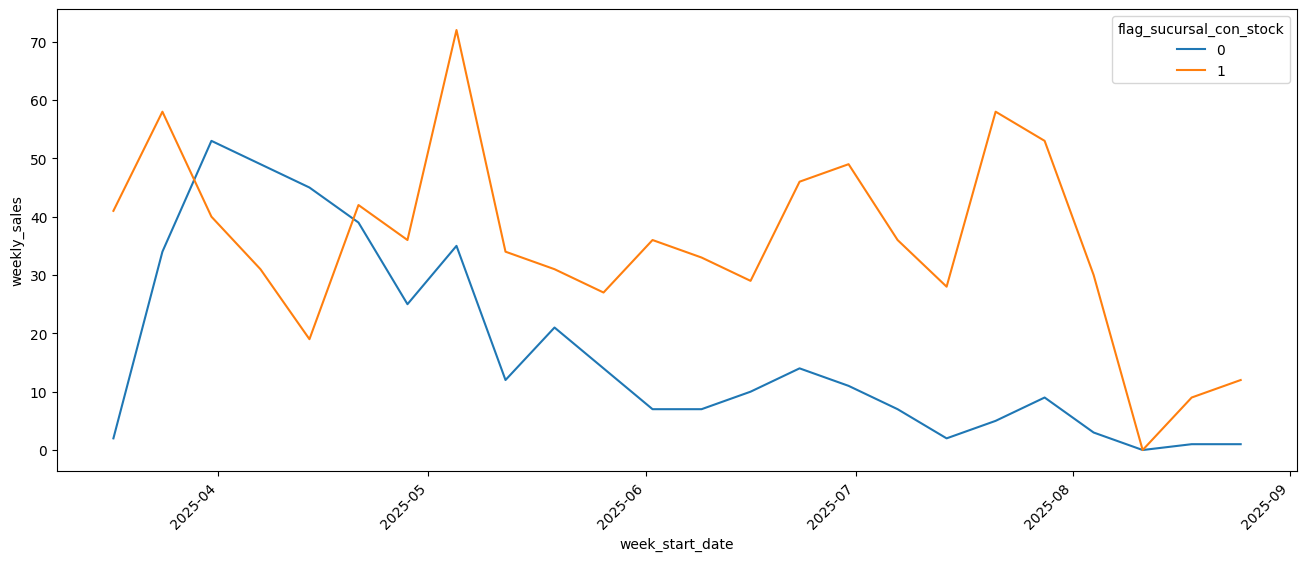

In [105]:
plt.figure(figsize=(16, 6))

sns.lineplot(
    data=sample_gb_suc,
    x='week_start_date',
    y='weekly_sales',
    hue='flag_sucursal_con_stock'
)

plt.xticks(rotation=45, ha='right')

plt.show()